In [25]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.cluster import KMeans 
from sklearn.datasets import make_blobs 

In [26]:
house_price_df = pd.read_csv(r"C:\Users\ARIO\Documents\ML_csv\house _price.csv")
house_price_df.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33


In [27]:
df=house_price_df.drop(columns='Price(USD)')
df.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price
0,63,1,True,True,True,Shahran,1.850000e+09
1,60,1,True,True,True,Shahran,1.850000e+09
2,79,2,True,True,True,Pardis,5.500000e+08
3,95,2,True,True,True,Shahrake Qods,9.025000e+08
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09


In [29]:
df.Address

0                  Shahran
1                  Shahran
2                   Pardis
3            Shahrake Qods
4           Shahrake Gharb
               ...        
3474    Southern Janatabad
3475              Niavaran
3476                Parand
3477                Dorous
3478                Parand
Name: Address, Length: 3479, dtype: object

In [30]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Address'] = le.fit_transform(df['Address'])
df.Address

0       156
1       156
2       117
3       152
4       150
       ... 
3474    163
3475    105
3476    115
3477     39
3478    115
Name: Address, Length: 3479, dtype: int64

In [31]:
df.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price
0,63,1,True,True,True,156,1.850000e+09
1,60,1,True,True,True,156,1.850000e+09
2,79,2,True,True,True,117,5.500000e+08
3,95,2,True,True,True,152,9.025000e+08
4,123,2,True,True,True,150,7.000000e+09


In [32]:
df['Parking'] = df['Parking'].astype(int)
df['Warehouse'] = df['Warehouse'].astype(int)


In [33]:
df.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price
0,63,1,1,1,True,156,1.850000e+09
1,60,1,1,1,True,156,1.850000e+09
2,79,2,1,1,True,117,5.500000e+08
3,95,2,1,1,True,152,9.025000e+08
4,123,2,1,1,True,150,7.000000e+09


In [34]:
print(df['Elevator'].unique())
print(df['Elevator'].apply(type).unique)

[ True False]
<bound method Series.unique of 0       <class 'bool'>
1       <class 'bool'>
2       <class 'bool'>
3       <class 'bool'>
4       <class 'bool'>
             ...      
3474    <class 'bool'>
3475    <class 'bool'>
3476    <class 'bool'>
3477    <class 'bool'>
3478    <class 'bool'>
Name: Elevator, Length: 3479, dtype: object>


In [36]:
df['Elevator'] = df['Elevator'].astype(int)
df.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price
0,63,1,1,1,1,156,1.850000e+09
1,60,1,1,1,1,156,1.850000e+09
2,79,2,1,1,1,117,5.500000e+08
3,95,2,1,1,1,152,9.025000e+08
4,123,2,1,1,1,150,7.000000e+09


In [42]:
print(df.dt)

Area          object
Room           int64
Parking        int64
Warehouse      int64
Elevator       int64
Address        int64
Price        float64
dtype: object


In [43]:
df['Area'] = df['Area'].astype(str).str.replace(',', '', regex=False).str.strip()
df['Area'] = pd.to_numeric(df['Area'], errors='coerce')

In [44]:
print(df.dtypes)

Area           int64
Room           int64
Parking        int64
Warehouse      int64
Elevator       int64
Address        int64
Price        float64
dtype: object


In [46]:
x = df.values[: , : ]
x = np.nan_to_num(x)

In [47]:
from sklearn.preprocessing import StandardScaler
Clus_dataSet = StandardScaler().fit_transform(x)
Clus_dataSet

array([[-0.02761117, -1.42436819,  0.42346432, ...,  0.51978033,
         0.99638872, -0.43327846],
       [-0.02761118, -1.42436819,  0.42346432, ...,  0.51978033,
         0.99638872, -0.43327846],
       [-0.02761112, -0.10539642,  0.42346432, ...,  0.51978033,
         0.22634157, -0.59379665],
       ...,
       [-0.02761114, -0.10539642, -2.36147402, ..., -1.92388964,
         0.18685197, -0.61663963],
       [-0.02761104, -0.10539642,  0.42346432, ...,  0.51978033,
        -1.31375273,  0.0297548 ],
       [-0.02761111, -0.10539642, -2.36147402, ...,  0.51978033,
         0.18685197, -0.617257  ]])

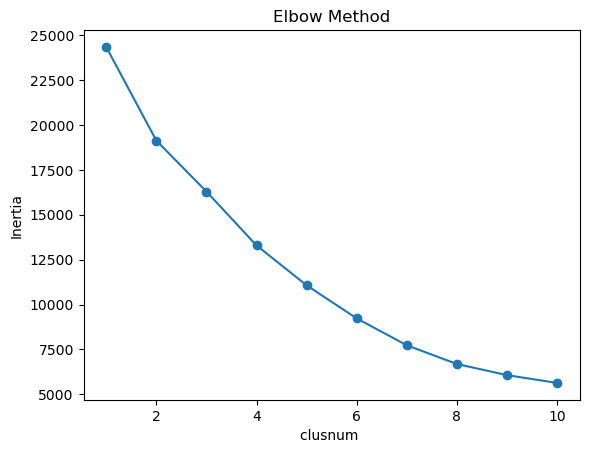

In [74]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(Clus_dataSet)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel('clusnum ')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [75]:
clusterNum = 5
k_means = KMeans(init = "k-means++", n_clusters = clusterNum, n_init = 12)
k_means.fit(Clus_dataSet)
labels = k_means.labels_
print(labels)

[0 0 0 ... 1 0 0]


In [76]:
df['clus_km']= labels
df.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price,clus_km
0,63,1,1,1,1,156,1.850000e+09,0
1,60,1,1,1,1,156,1.850000e+09,0
2,79,2,1,1,1,117,5.500000e+08,0
3,95,2,1,1,1,152,9.025000e+08,0
4,123,2,1,1,1,150,7.000000e+09,0


In [77]:
df.groupby('clus_km').mean()

,Area,Room,Parking,Warehouse,Elevator,Address,Price
clus_km,,,,,,,
0,2.895348e+06,1.917490,0.936759,1.000000,1.000000,112.231225,3.394096e+09
1,1.001182e+02,1.746622,0.337838,0.000000,0.516892,103.540541,2.424220e+09
2,1.925506e+02,3.192371,0.998342,0.998342,0.928690,88.084577,1.656187e+10
3,8.270939e+01,1.638989,0.631769,1.000000,0.000000,101.205776,1.886553e+09
4,1.228000e+10,2.500000,1.000000,1.000000,1.000000,87.500000,1.243000e+10


In [78]:
df.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price,clus_km
0,63,1,1,1,1,156,1.850000e+09,0
1,60,1,1,1,1,156,1.850000e+09,0
2,79,2,1,1,1,117,5.500000e+08,0
3,95,2,1,1,1,152,9.025000e+08,0
4,123,2,1,1,1,150,7.000000e+09,0


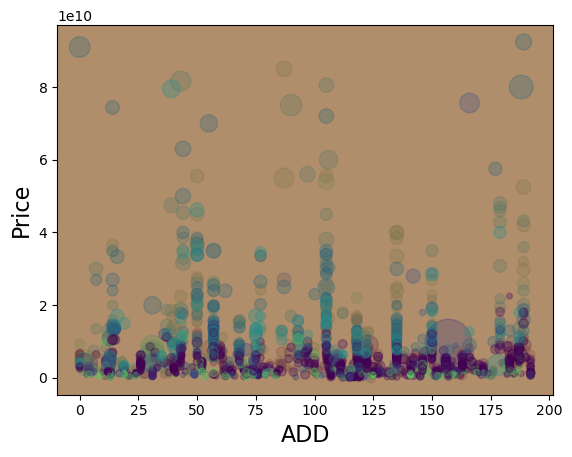

In [89]:
area = np.pi * (x[:,0])/10
plt.scatter(x[:,5],x[:,6],s=area,c=labels.astype(np.float16),alpha=0.3)
plt.xlabel("ADD",fontsize=16)
plt.ylabel("Price",fontsize=16)
plt.show()

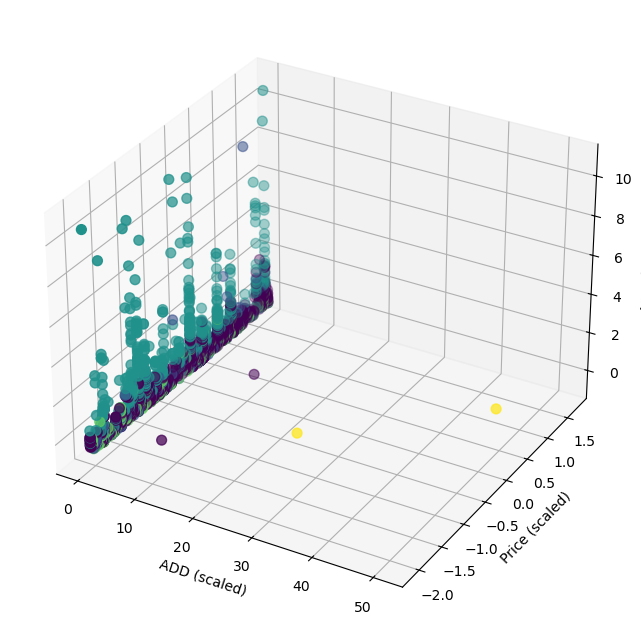

In [81]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(Clus_dataSet[:, 0], Clus_dataSet[:, 5], Clus_dataSet[:, 6], c=labels, cmap='viridis', s=50)
ax.set_xlabel('ADD (scaled)')
ax.set_ylabel('Price (scaled)')
ax.set_zlabel('Area (scaled)')
plt.show()